# Nearly Free Electron

Using the argument of mixing of plane waves as the potential is switched on feebly enough to be treated as perturbation,
show that the bands will have zero slope at the middle and edges of the BZs. Recall in class how we defined 1st, 2nd, 3rd ... Brillouin zones.

Show that the band-gaps between the bands primarily depend on the strength of the harmonics in the decomposition of the periodic potential.

In [131]:
import numpy as np
import matplotlib.pyplot as plt

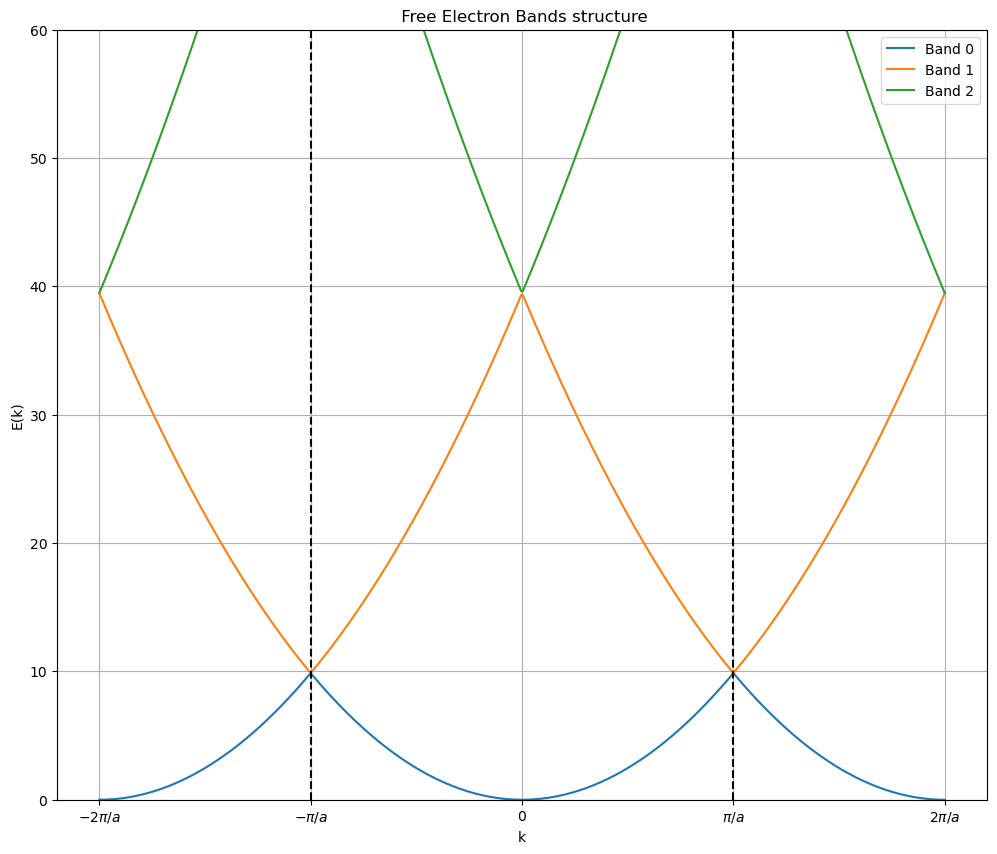

In [132]:
a = 1.0
G = 2*np.pi/a
basis_m = np.arange(-4, 5)

k_vals = np.linspace(-2*np.pi/a, 2*np.pi/a, 600)
bds = []
for k in k_vals:
    size = len(basis_m)
    H = np.zeros((size, size))
    
    for i, m in enumerate(basis_m):
        H[i, i] = (k + m*G)**2
        
    eigvals = np.linalg.eigvalsh(H)
    bds.append(eigvals)

bds = np.array(bds)

plt.figure(figsize=(12,10))

for n in range(3):
    plt.plot(k_vals, bds[:, n], label=f"Band {n}")
plt.axvline(np.pi/a, linestyle='--', color='black')
plt.axvline(-np.pi/a, linestyle='--', color='black')
tp = [
    -2*np.pi/a,
    -np.pi/a,
    0,
    np.pi/a,
    2*np.pi/a
]
tl = [
    r"$-2\pi/a$",
    r"$-\pi/a$",
    r"$0$",
    r"$\pi/a$",
    r"$2\pi/a$"
]
plt.xticks(tp, tl)
plt.ylim(0, 60)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title(" Free Electron Bands structure")
plt.grid(True)
plt.legend()
plt.show()

This is the free electron band structure. Now we introduce a potential with 2 harmonics of cosine with periodicity in 'a'.

We applied degenerate pertubation theory to conclude that band gaps must appear near the edge of the BZ (see calculations pdf attached). Also their slope must be zero at the edges and the middle of BZ. 

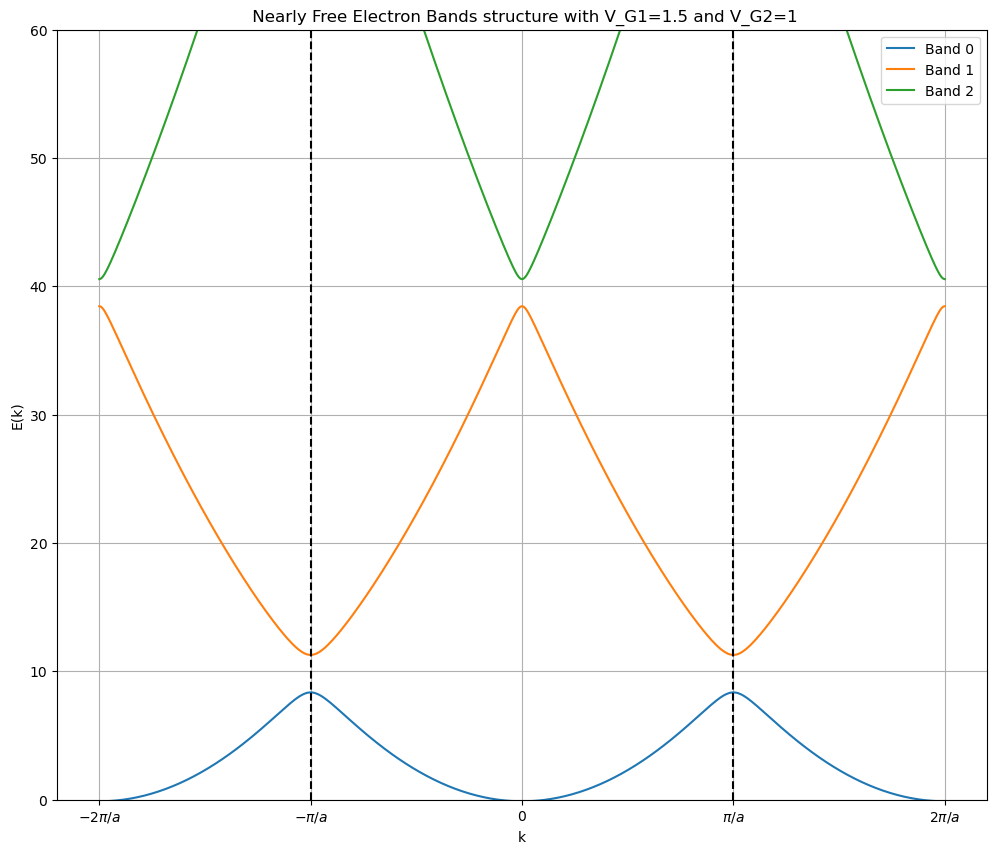

In [133]:
V1 = 1.5
V2 = 1
bands = []

for k in k_vals:
    size = len(basis_m)
    H = np.zeros((size, size))
    
    for i, m in enumerate(basis_m):
        H[i, i] = (k + m*G)**2
        
        if i+1 < size:
            H[i, i+1] = V1
            H[i+1, i] = V1
            
        if i+2 < size:
            H[i, i+2] = V2
            H[i+2, i] = V2

    eigvals = np.linalg.eigvalsh(H)
    bands.append(eigvals)

bands = np.array(bands)

plt.figure(figsize=(12,10))
for n in range(3):
    plt.plot(k_vals, bands[:, n], label=f"Band {n}")
plt.axvline(np.pi/a, linestyle='--', color='black')
plt.axvline(-np.pi/a, linestyle='--', color='black')
plt.xticks(tp, tl)
plt.ylim(0, 60)
plt.xlabel("k")
plt.ylabel("E(k)")
plt.title(" Nearly Free Electron Bands structure with V_G1=1.5 and V_G2=1")
plt.grid(True)
plt.legend()
plt.show()

We observe that the 1st band gap is governed by the first harmonic strength V_G1 as shown by our calculations (see attached pdf) 

Also, the 2nd band gap is governed by the strength of the 2nd harmonic as expected.

A larger gap is observed for n=0 and n=1 band gap and a smaller gap is observed for n=1 and n=2 band. This is consistent with our considerations of strength of the harmonics i.e. V_G1 = 1.5 and V_G2 = 1.


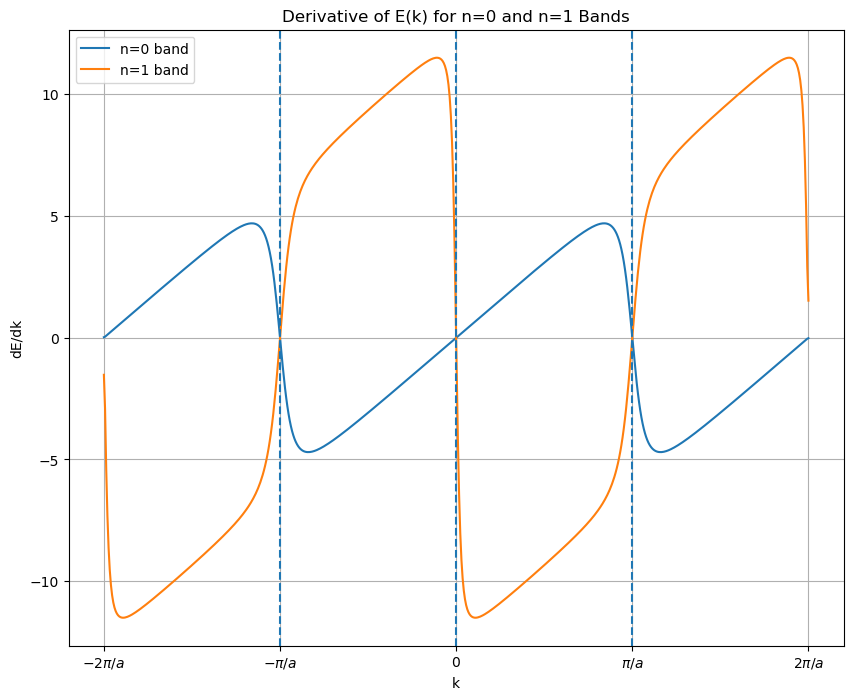

In [134]:
bands = np.array(bands)

# First and second bands
E1 = bands[:, 0]
E2 = bands[:, 1]

# Numerical derivatives
dE1_dk = np.gradient(E1, k_vals)
dE2_dk = np.gradient(E2, k_vals)

# Plot both derivatives
plt.figure(figsize=(10,8))
plt.plot(k_vals, dE1_dk, label="n=0 band")
plt.plot(k_vals, dE2_dk, label="n=1 band")

# Mark symmetry points
plt.axvline(0, linestyle='--')
plt.axvline(np.pi/a, linestyle='--')
plt.axvline(-np.pi/a, linestyle='--')
plt.xticks(tp, tl)
plt.grid(True)
plt.xlabel("k")
plt.ylabel("dE/dk")
plt.title("Derivative of E(k) for n=0 and n=1 Bands")
plt.legend()
plt.show()

Hence, we observe that the derivative of energy plot goes to zero at the edges of brillouin zone for n=0 band and at the middle of BZ for n=1 band. 